In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report

In [2]:
# Preprocessing
df = pd.read_csv('maternal_health_risk_dataset.csv')
df.replace({'RiskLevel': {'low risk': 0, 'mid risk': 1, 'high risk': 2}}, inplace=True)

In [3]:
# Model Training
X = df.drop(columns='RiskLevel')
y = df['RiskLevel']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [4]:
# Model Evaluation
print(classification_report(y_test, y_pred, target_names=['low risk', 'mid risk', 'high risk']))

skf = StratifiedKFold(n_splits=5)
scores = cross_val_score(clf, X, y, cv=skf)
print("CV scores:", scores)
print("Mean:", scores.mean(), "Std:", scores.std())

              precision    recall  f1-score   support

    low risk       0.86      0.76      0.81        80
    mid risk       0.74      0.84      0.79        76
   high risk       0.87      0.85      0.86        47

    accuracy                           0.81       203
   macro avg       0.82      0.82      0.82       203
weighted avg       0.82      0.81      0.81       203

CV scores: [0.91133005 0.72413793 0.81773399 0.78325123 0.87623762]
Mean: 0.822538165146564 Std: 0.06635778758245277


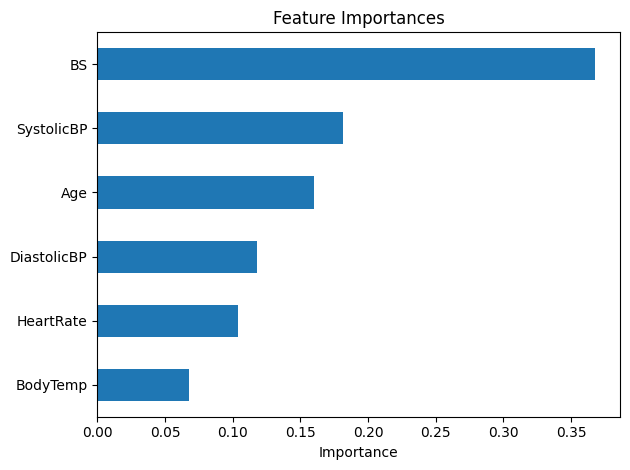

In [5]:
# See Feature Weighting
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [6]:
# Predict w/ an actual patient
print(X.columns.tolist())

patient = pd.DataFrame([{
    'Age': 25,
    'SystolicBP': 120,
    'DiastolicBP': 80,
    'BS': 6.5,
    'BodyTemp': 98.6,
    'HeartRate': 76
}])

prediction = clf.predict(patient)
risk_names = {0: 'low risk', 1: 'mid risk', 2: 'high risk'}
print("Predicted risk level:", risk_names[prediction[0]])

['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
Predicted risk level: low risk


# Getting an API connection to the prediction model to connect to front end

In [9]:
import pickle

# Save the model
with open("model.pkl", "wb") as f:
    pickle.dump(clf, f)

# Load the model
with open("model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# Make predictions with the loaded model
print(loaded_model.predict(patient))

[0]


In [13]:
#!pip install litserve

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 456.6/456.6 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 456.1/456.1 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.6/184.6 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.4/114.4 kB 14.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import litserve as ls

# STEP 1: DEFINE YOUR MODEL API
class SimpleLitAPI(ls.LitAPI):
    def setup(self, device):
        self.model = lambda x: x**2

    def decode_request(self, request):
        return request["input"]

    def predict(self, x):
        return self.model(x)

    def encode_response(self, output):
        return {"output": output}

# STEP 2: START THE SERVER
if __name__ == "__main__":
    api = SimpleLitAPI()
    server = ls.LitServer(api, accelerator="auto")
    server.run(port=8000)

INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/usr/local/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'SimpleLitAPI' on <module '__main__' (built-in)>


In [7]:
# Goals

# High blood sugar: >= 95
# High blood pressure: >= 140/90 mmHg

EXERCISE_DAILY = [
    "Do 30 minutes of exercise",
    "Walk for 5-30 minutes",
    "Do pelvic floor exercises",
    "Do yoga for 10-30 minutes"
]

NUTRITION_DAILY = [
    "Drink 3 cups of milk",
    "Take prenatal vitamins",
    "Eat 2.5 cups of vegetables",
    "Eat 2 cups of fruits"
]

HYDRATION_DAILY = [
    "Drink 8 cups of water"
]

SLEEP_DAILY = [
    "Get 8 hours of sleep"
]


EXERCISE_WEEKLY = [
    "Exercise at least 5 days",
    "Increase exercise duration by 5 minutes",
    "Complete 2 strength/core sessions"
]

NUTRITION_WEEKLY = [
    "Eat leafy greens at least 4 days",
    "Eat poultry 1-2 times",
    "Include legumes in 3 meals"
]

CHECKUP_WEEKLY = [
    "Schedule appointment",
    "Attend check-up"
]

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a821b658-b50e-44ad-b86f-d4439f0bec8a' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>